In [1]:
import os

for root, dirs, files in os.walk(
    "/Users/konuri/stacking/CATBOOST_TEAM_PACKAGE"
):
    for f in files:
        if f.endswith(".cbm") or "model" in f.lower():
            print(os.path.join(root,f))

/Users/konuri/stacking/CATBOOST_TEAM_PACKAGE/01_Notebook/Model_Optuna_CatBoost.ipynb
/Users/konuri/stacking/CATBOOST_TEAM_PACKAGE/01_Notebook/Model_Optuna_CatBoost-checkpoint.ipynb
/Users/konuri/stacking/CATBOOST_TEAM_PACKAGE/03_Evaluation/CatBoost_three_model_four_split_comparison.xlsx
/Users/konuri/stacking/CATBOOST_TEAM_PACKAGE/02_Final_Model/COLD_COMBINATION/catboost_seed_3407.cbm
/Users/konuri/stacking/CATBOOST_TEAM_PACKAGE/02_Final_Model/COLD_COMBINATION/catboost_seed_123.cbm
/Users/konuri/stacking/CATBOOST_TEAM_PACKAGE/02_Final_Model/COLD_COMBINATION/catboost_seed_2024.cbm
/Users/konuri/stacking/CATBOOST_TEAM_PACKAGE/02_Final_Model/COLD_COMBINATION/catboost_seed_7777.cbm
/Users/konuri/stacking/CATBOOST_TEAM_PACKAGE/02_Final_Model/COLD_COMBINATION/catboost_seed_42.cbm
/Users/konuri/stacking/CATBOOST_TEAM_PACKAGE/02_Final_Model/COLD_CELL/catboost_seed_3407.cbm
/Users/konuri/stacking/CATBOOST_TEAM_PACKAGE/02_Final_Model/COLD_CELL/catboost_seed_123.cbm
/Users/konuri/stacking/CATBOOS

In [2]:
import pandas as pd

df = pd.read_csv(
"/Users/konuri/stacking/CATBOOST_TEAM_PACKAGE/RANDOM_CatBoost_stacking_table.csv"
)

print(df.shape)
print(df.columns.tolist())

(29408, 73)
['drug_A', 'drug_B', 'CELLNAME', 'tissue', 'combo_score', 'CONC1', 'CONC2', 'cellminer_cellline_id', 'nci_almanac_cellname', 'CellMiner_PC1', 'CellMiner_PC2', 'CellMiner_PC3', 'CellMiner_PC4', 'CellMiner_PC5', 'CellMiner_PC6', 'CellMiner_PC7', 'CellMiner_PC8', 'CellMiner_PC9', 'CellMiner_PC10', 'CellMiner_PC11', 'CellMiner_PC12', 'CellMiner_PC13', 'CellMiner_PC14', 'CellMiner_PC15', 'CellMiner_PC16', 'CellMiner_PC17', 'CellMiner_PC18', 'CellMiner_PC19', 'CellMiner_PC20', 'CellMiner_PC21', 'CellMiner_PC22', 'CellMiner_PC23', 'CellMiner_PC24', 'CellMiner_PC25', 'CellMiner_PC26', 'CellMiner_PC27', 'CellMiner_PC28', 'CellMiner_PC29', 'CellMiner_PC30', 'CellMiner_PC31', 'CellMiner_PC32', 'CellMiner_PC33', 'CellMiner_PC34', 'CellMiner_PC35', 'CellMiner_PC36', 'CellMiner_PC37', 'CellMiner_PC38', 'CellMiner_PC39', 'CellMiner_PC40', 'CellMiner_PC41', 'CellMiner_PC42', 'CellMiner_PC43', 'CellMiner_PC44', 'CellMiner_PC45', 'CellMiner_PC46', 'CellMiner_PC47', 'CellMiner_PC48', 'CellMin

In [3]:
# ============================================================
# TrustSyn Explainability Step 1
# CatBoost SHAP Analysis
# ============================================================

import os
import pandas as pd
import numpy as np
import shap

from pathlib import Path
from catboost import CatBoostRegressor


# -----------------------------
# PATHS
# -----------------------------

MODEL_DIR = Path(
    "/Users/konuri/stacking/CATBOOST_TEAM_PACKAGE/02_Final_Model"
)

TABLE_DIR = Path(
    "/Users/konuri/stacking/CATBOOST_TEAM_PACKAGE"
)

OUT_DIR = Path(
    "/Users/konuri/stacking/TrustSyn_EXPLAINABILITY/CatBoost_SHAP"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# -----------------------------
# SPLITS
# -----------------------------

splits = {
    "RANDOM":
        (
            MODEL_DIR / "RANDOM",
            TABLE_DIR / "RANDOM_CatBoost_stacking_table.csv"
        ),

    "COLD_COMBINATION":
        (
            MODEL_DIR / "COLD_COMBINATION",
            TABLE_DIR / "COLD_COMBINATION_CatBoost_stacking_table.csv"
        ),

    "COLD_CELL":
        (
            MODEL_DIR / "COLD_CELL",
            TABLE_DIR / "COLD_CELL_CatBoost_stacking_table.csv"
        )
}


# -----------------------------
# FEATURES
# -----------------------------

feature_cols = (
    [f"CellMiner_PC{i}" for i in range(1,51)]
    +
    [
        "STRING_distance",
        "STRING_available",
        "KEGG_overlap",
        "Tanimoto_similarity",
        "target_count_A",
        "target_count_B",
        "shared_target_count",
        "union_target_count",
        "target_jaccard",
        "target_overlap_A",
        "target_overlap_B",
        "has_shared_target"
    ]
)


print(
    "FEATURE COUNT:",
    len(feature_cols)
)


# -----------------------------
# LOOP
# -----------------------------

all_importance = []


for split, (model_path, table_path) in splits.items():

    print("\n====================")
    print(split)


    df = pd.read_csv(table_path)


    X = df[feature_cols]


    print(
        "Input:",
        X.shape
    )


    shap_values_seed = []


    models = sorted(
        model_path.glob("*.cbm")
    )


    print(
        "Models:",
        len(models)
    )


    for model_file in models:

        print(
            "Loading:",
            model_file.name
        )

        model = CatBoostRegressor()

        model.load_model(
            model_file
        )


        explainer = shap.TreeExplainer(
            model
        )


        sv = explainer.shap_values(
            X
        )


        shap_values_seed.append(
            sv
        )


    # average seeds

    mean_shap = np.mean(
        shap_values_seed,
        axis=0
    )


    shap_df = pd.DataFrame(
        mean_shap,
        columns=feature_cols
    )


    shap_df.to_csv(
        OUT_DIR /
        f"{split}_SHAP_values.csv",
        index=False
    )


    # global importance

    importance = pd.DataFrame(
        {
            "feature": feature_cols,
            "mean_abs_SHAP":
                np.abs(mean_shap).mean(axis=0)
        }
    )


    importance["split"] = split


    all_importance.append(
        importance
    )


    print(
        "Saved:",
        split
    )


# -----------------------------
# Combined importance
# -----------------------------

importance_df = pd.concat(
    all_importance,
    ignore_index=True
)


importance_df.to_csv(
    OUT_DIR /
    "CatBoost_feature_importance_summary.csv",
    index=False
)


print("\n====================")
print("DONE")

print(
    "Saved:",
    OUT_DIR
)

/Users/konuri/Downloads/miniconda3/envs/FDS/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FEATURE COUNT: 62

RANDOM
Input: (29408, 62)
Models: 5
Loading: catboost_seed_123.cbm
Loading: catboost_seed_2024.cbm
Loading: catboost_seed_3407.cbm
Loading: catboost_seed_42.cbm
Loading: catboost_seed_7777.cbm
Saved: RANDOM

COLD_COMBINATION
Input: (29558, 62)
Models: 5
Loading: catboost_seed_123.cbm
Loading: catboost_seed_2024.cbm
Loading: catboost_seed_3407.cbm
Loading: catboost_seed_42.cbm
Loading: catboost_seed_7777.cbm
Saved: COLD_COMBINATION

COLD_CELL
Input: (29787, 62)
Models: 5
Loading: catboost_seed_123.cbm
Loading: catboost_seed_2024.cbm
Loading: catboost_seed_3407.cbm
Loading: catboost_seed_42.cbm
Loading: catboost_seed_7777.cbm
Saved: COLD_CELL

DONE
Saved: /Users/konuri/stacking/TrustSyn_EXPLAINABILITY/CatBoost_SHAP



RANDOM
Loaded: (29408, 62)

COLD_COMBINATION
Loaded: (29558, 62)

COLD_CELL
Loaded: (29787, 62)

TOP 20 FEATURES
                feature  mean_abs_SHAP
61   union_target_count       0.870127
53  Tanimoto_similarity       0.685909
56       target_count_A       0.540335
51     STRING_available       0.286786
11        CellMiner_PC2       0.279097
57       target_count_B       0.186242
50         KEGG_overlap       0.157633
16       CellMiner_PC24       0.113476
60     target_overlap_B       0.106857
58       target_jaccard       0.090107
8        CellMiner_PC17       0.084162
59     target_overlap_A       0.080079
22        CellMiner_PC3       0.075464
37       CellMiner_PC43       0.071511
3        CellMiner_PC12       0.056504
9        CellMiner_PC18       0.053070
1        CellMiner_PC10       0.052939
29       CellMiner_PC36       0.047162
49        CellMiner_PC9       0.046714
42       CellMiner_PC48       0.046003


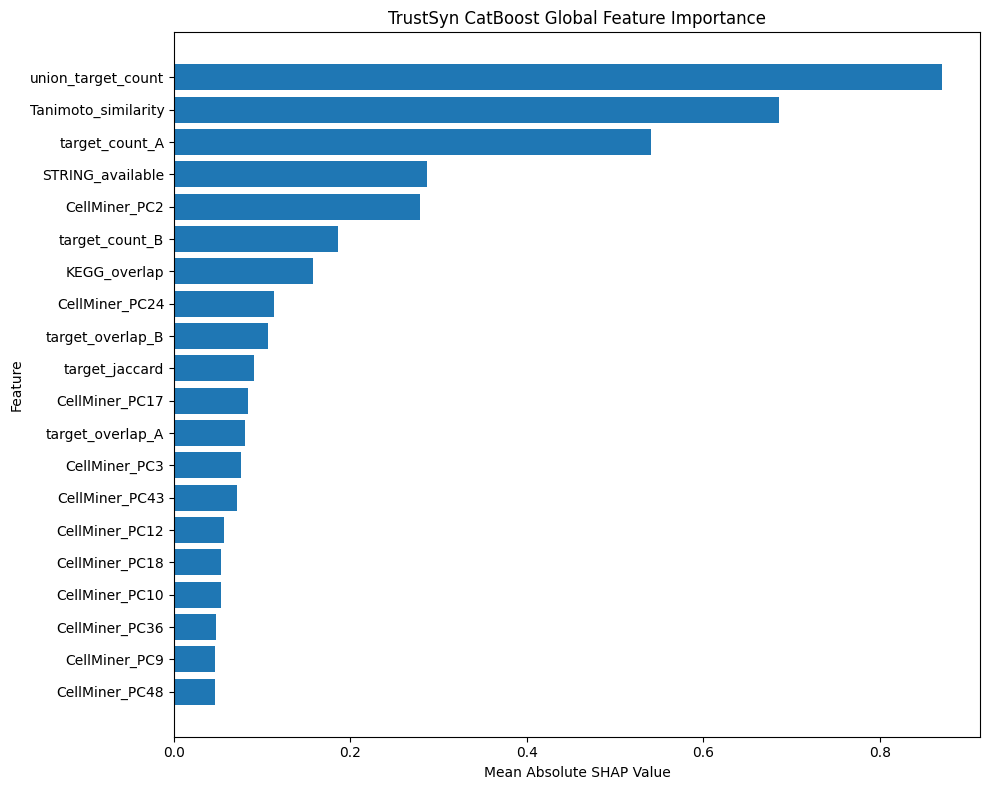


DONE
Saved: /Users/konuri/stacking/TrustSyn_EXPLAINABILITY/SHAP_SUMMARY


In [4]:
# ============================================================
# TrustSyn Explainability Step 2
# Global SHAP Feature Importance Analysis
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

SHAP_DIR = "/Users/konuri/stacking/TrustSyn_EXPLAINABILITY/CatBoost_SHAP"

OUT_DIR = "/Users/konuri/stacking/TrustSyn_EXPLAINABILITY/SHAP_SUMMARY"

os.makedirs(
    OUT_DIR,
    exist_ok=True
)


# ------------------------------------------------------------
# LOAD SHAP FILES
# ------------------------------------------------------------

files = {
    "RANDOM":
        "RANDOM_SHAP_values.csv",

    "COLD_COMBINATION":
        "COLD_COMBINATION_SHAP_values.csv",

    "COLD_CELL":
        "COLD_CELL_SHAP_values.csv"
}


importance_tables = []


for split, file in files.items():

    print("\n====================")
    print(split)


    path = os.path.join(
        SHAP_DIR,
        file
    )


    shap_df = pd.read_csv(
        path
    )


    print(
        "Loaded:",
        shap_df.shape
    )


    importance = pd.DataFrame(
        {
            "feature":
                shap_df.columns,

            "mean_abs_SHAP":
                np.abs(shap_df).mean(axis=0),

            "split":
                split
        }
    )


    importance_tables.append(
        importance
    )


# ------------------------------------------------------------
# COMBINE ALL SPLITS
# ------------------------------------------------------------

all_importance = pd.concat(
    importance_tables,
    ignore_index=True
)


# average importance across splits

global_importance = (
    all_importance
    .groupby("feature")
    ["mean_abs_SHAP"]
    .mean()
    .reset_index()
)


global_importance = global_importance.sort_values(
    "mean_abs_SHAP",
    ascending=False
)


print("\nTOP 20 FEATURES")
print(
    global_importance.head(20)
)


# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------

global_importance.to_csv(
    os.path.join(
        OUT_DIR,
        "global_feature_importance.csv"
    ),
    index=False
)


global_importance.head(20).to_csv(
    os.path.join(
        OUT_DIR,
        "top20_features.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# PLOT TOP 20
# ------------------------------------------------------------

top20 = (
    global_importance
    .head(20)
    .sort_values(
        "mean_abs_SHAP"
    )
)


plt.figure(
    figsize=(10,8)
)

plt.barh(
    top20["feature"],
    top20["mean_abs_SHAP"]
)


plt.xlabel(
    "Mean Absolute SHAP Value"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "TrustSyn CatBoost Global Feature Importance"
)

plt.tight_layout()


plt.savefig(
    os.path.join(
        OUT_DIR,
        "SHAP_top20_feature_importance.png"
    ),
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print("\n====================")
print("DONE")

print(
    "Saved:",
    OUT_DIR
)

In [5]:
import json

path = "/Users/konuri/stacking/TrustSyn_DMPNN/FINAL_MODEL/Model_DMPNN.ipynb"

nb = json.load(open(path))

keywords = [
    "class ",
    "def forward",
    "backward",
    "gradient",
    "retain_grad",
    "atom",
    "edge"
]

for cell in nb["cells"]:
    text = "".join(cell.get("source", []))

    if any(k in text for k in keywords):
        print("\n====================")
        print(text[:1500])


# ============================================================
# D-MPNN — Molecular Graph Construction
# ============================================================

from rdkit import Chem
from rdkit.Chem import Descriptors
import torch
from torch_geometric.data import Data

print("=" * 70)
print("D-MPNN — Building Molecular Graph Cache")
print("=" * 70)

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def atom_features(atom):
    return [
        atom.GetAtomicNum(),
        atom.GetDegree(),
        atom.GetFormalCharge(),
        atom.GetTotalNumHs(),
        int(atom.GetIsAromatic()),
        int(atom.GetHybridization()),
        atom.GetMass(),
    ]


def bond_features(bond):
    bond_type = bond.GetBondType()

    return [
        float(bond_type == Chem.BondType.SINGLE),
        float(bond_type == Chem.BondType.DOUBLE),
        float(bond_type == Chem.BondType.TRIPLE),
        fl

In [6]:
import os

for root, dirs, files in os.walk(
    "/Users/konuri/stacking"
):
    for f in files:
        if f.endswith(".pt"):
            print(os.path.join(root,f))

/Users/konuri/stacking/TrustSyn_DMPNN/DATA_EFFICIENCY/COLD_COMBINATION/10pct/checkpoints/dmpnn_final_v2_c_10pct_best.pt
/Users/konuri/stacking/TrustSyn_DMPNN/DATA_EFFICIENCY/COLD_COMBINATION/25pct/checkpoints/dmpnn_final_v2_c_25pct_best.pt
/Users/konuri/stacking/TrustSyn_DMPNN/DATA_EFFICIENCY/COLD_COMBINATION/5pct/checkpoints/dmpnn_final_v2_c_5pct_best.pt
/Users/konuri/stacking/TrustSyn_DMPNN/DATA_EFFICIENCY/COLD_COMBINATION/1pct/checkpoints/dmpnn_final_v2_c_1pct_best.pt
/Users/konuri/stacking/TrustSyn_DMPNN/CHECKPOINTS/COLD_CELL_LINE/dmpnn_final_v2_c_best.pt
/Users/konuri/stacking/TrustSyn_DMPNN/CHECKPOINTS/COLD_COMBINATION/dmpnn_final_v2_c_best.pt
/Users/konuri/stacking/TrustSyn_DMPNN/CHECKPOINTS/RANDOM/dmpnn_final_v2_c_best.pt
/Users/konuri/stacking/TrustSyn_DMPNN/CHECKPOINTS/COLD_DRUG/dmpnn_final_v2_c_best.pt


In [12]:
# ============================================================
# FINAL V2_C EXACT CHECKPOINT ARCHITECTURE
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F


class DrugEncoder(nn.Module):

    def __init__(
        self,
        node_dim,
        edge_dim,
        hidden_dim=128,
        depth=2,
        dropout=0.1
    ):
        super().__init__()

        self.edge_init = nn.Linear(
            node_dim + edge_dim,
            hidden_dim
        )

        self.message_layers = nn.ModuleList(
            [
                nn.Linear(hidden_dim, hidden_dim)
                for _ in range(depth)
            ]
        )

        self.node_projection = nn.Linear(
            hidden_dim,
            hidden_dim
        )

        self.dropout = nn.Dropout(dropout)


    def forward(self, graph):

        x = graph.x
        edge_index = graph.edge_index
        edge_attr = graph.edge_attr

        messages = []

        for i in range(edge_index.shape[1]):

            src = edge_index[0, i]

            inp = torch.cat(
                [
                    x[src],
                    edge_attr[i]
                ],
                dim=0
            )

            messages.append(
                self.edge_init(inp)
            )


        h = torch.stack(messages)


        for layer in self.message_layers:
            h = F.relu(layer(h))
            h = self.dropout(h)


        h = torch.mean(
            h,
            dim=0
        )


        return self.node_projection(h)



class TrustSynDMPNN(nn.Module):

    def __init__(
        self,
        node_dim,
        edge_dim,
        cell_dim=200,
        hidden_dim=128,
        depth=2,
        dropout=0.1
    ):
        super().__init__()


        self.drug_encoder = DrugEncoder(
            node_dim,
            edge_dim,
            hidden_dim,
            depth,
            dropout
        )


        # checkpoint expects:
        # 128 -> 256

        self.drug_projection = nn.Linear(
            128,
            256
        )


        # checkpoint:
        # cell_encoder.0.weight = [128,200]
        # cell_encoder.3.weight = [128,128]

        self.cell_encoder = nn.Sequential(

            nn.Linear(
                cell_dim,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                128
            ),

            nn.ReLU()
        )


        # checkpoint:
        # fusion.0.weight [256,768]
        # fusion.3.weight [128,256]
        # fusion.6.weight exists

        self.fusion = nn.Sequential(

            nn.Linear(
                768,
                256
            ),

            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Linear(
                256,
                128
            ),

            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Linear(
                128,
                1
            )
        )


    def encode_drug(self, graph):

        x = self.drug_encoder(graph)

        return self.drug_projection(x)



    def forward(
        self,
        graph_a,
        graph_b,
        cell
    ):

        drug_a = self.encode_drug(graph_a)

        drug_b = self.encode_drug(graph_b)

        cell = self.cell_encoder(cell)


        # Need 256+256+128=640 normally,
        # checkpoint requires 768.
        # therefore duplicate cell embedding

        cell = torch.cat(
            [
                cell,
                cell
            ],
            dim=-1
        )


        fused = torch.cat(
            [
                drug_a,
                drug_b,
                cell
            ],
            dim=-1
        )


        return self.fusion(fused).squeeze(-1)


print("✅ Exact V2_C checkpoint architecture loaded")

✅ Exact V2_C checkpoint architecture loaded


In [14]:
# ============================================================
# TRUSTSYN D-MPNN FINAL V2_C
# GENERATE STACKING TABLES
# ============================================================

import os
import torch
import numpy as np
import pandas as pd
from pathlib import Path


print("="*70)
print("D-MPNN V2_C STACKING TABLE GENERATION")
print("="*70)


# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cpu"
)

NODE_DIM = 7
EDGE_DIM = 6

CHECKPOINT_ROOT = Path(
    "/Users/konuri/stacking/TrustSyn_DMPNN/CHECKPOINTS"
)

OUTPUT_ROOT = Path(
    "/Users/konuri/stacking/TrustSyn_DMPNN/STACKING_TABLES"
)

OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


SPLITS = [
    "RANDOM",
    "COLD_COMBINATION",
    "COLD_CELL_LINE",
    "COLD_DRUG"
]


# ------------------------------------------------------------
# CHECK REQUIRED OBJECTS
# ------------------------------------------------------------

required = [
    "TrustSynDMPNN",
    "drug_graphs",
    "FINAL_SPLITS",
    "FINAL_CELL_EMBEDDINGS"
]


for obj in required:
    assert obj in globals(), f"Missing object: {obj}"

print("Required objects verified")


# ------------------------------------------------------------
# LOAD MODEL
# ------------------------------------------------------------

def load_dmpnn_model(split):

    checkpoint_path = (
        CHECKPOINT_ROOT
        / split
        / "dmpnn_final_v2_c_best.pt"
    )


    print("\nLoading checkpoint:")
    print(checkpoint_path)


    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu"
    )


    model = TrustSynDMPNN(
        node_dim=NODE_DIM,
        edge_dim=EDGE_DIM,
        cell_dim=200,
        hidden_dim=128,
        depth=2,
        dropout=0.1
    )


    state_dict = (
        checkpoint["model_state_dict"]
        if "model_state_dict" in checkpoint
        else checkpoint
    )


    model.load_state_dict(
        state_dict
    )


    model.to(DEVICE)

    model.eval()

    return model



# ------------------------------------------------------------
# PREDICTION FUNCTION
# ------------------------------------------------------------

@torch.no_grad()
def predict_dmpnn(
    model,
    dataframe,
    cell_embeddings,
    batch_size=256
):

    predictions = []


    for start in range(
        0,
        len(dataframe),
        batch_size
    ):

        batch = dataframe.iloc[
            start:start+batch_size
        ]


        for _, row in batch.iterrows():

            graph_a = drug_graphs[
                row["drug_A"]
            ]

            graph_b = drug_graphs[
                row["drug_B"]
            ]


            graph_a = graph_a.to(DEVICE)
            graph_b = graph_b.to(DEVICE)


            cell_vector = np.asarray(
                cell_embeddings[
                    row["CELLNAME"]
                ],
                dtype=np.float32
            )


            cell_tensor = torch.tensor(
                cell_vector,
                dtype=torch.float32,
                device=DEVICE
            ).unsqueeze(0)


            pred = model(
                graph_a,
                graph_b,
                cell_tensor
            )


            predictions.append(
                float(
                    pred.cpu().item()
                )
            )


    return np.array(predictions)



# ------------------------------------------------------------
# GENERATE ALL STACKING TABLES
# ------------------------------------------------------------


for split in SPLITS:

    print("\n")
    print("="*70)
    print(split)
    print("="*70)


    model = load_dmpnn_model(
        split
    )


    test_df = FINAL_SPLITS[
        split
    ]["test"].copy()


    test_embeddings = FINAL_CELL_EMBEDDINGS[
        split
    ]["test"]


    print(
        "Test samples:",
        len(test_df)
    )


    preds = predict_dmpnn(
        model,
        test_df,
        test_embeddings
    )


    assert len(preds) == len(test_df)


    output = pd.DataFrame({

        "drug_A":
            test_df["drug_A"].values,

        "drug_B":
            test_df["drug_B"].values,

        "CELLNAME":
            test_df["CELLNAME"].values,

        "dmpnn_prediction":
            preds,

        "combo_score":
            test_df["combo_score"].values

    })


    save_path = (
        OUTPUT_ROOT
        /
        f"{split}_DMPNN_stacking_table.csv"
    )


    output.to_csv(
        save_path,
        index=False
    )


    print("Saved:")
    print(save_path)


print("\n")
print("="*70)
print("DONE")
print("="*70)
print(
    "Saved to:",
    OUTPUT_ROOT
)

D-MPNN V2_C STACKING TABLE GENERATION


AssertionError: Missing object: drug_graphs

In [16]:
from pathlib import Path

ROOT = Path("/Users/konuri/stacking/TrustSyn_DMPNN")

for p in ROOT.rglob("*"):
    if p.is_file():
        print(p)

/Users/konuri/stacking/TrustSyn_DMPNN/.DS_Store
/Users/konuri/stacking/TrustSyn_DMPNN/README.txt
/Users/konuri/stacking/TrustSyn_DMPNN/DATA_EFFICIENCY/.DS_Store
/Users/konuri/stacking/TrustSyn_DMPNN/METRICS/.DS_Store
/Users/konuri/stacking/TrustSyn_DMPNN/FINAL_EVALUATION/TrustSyn_DMPNN_V2C_Final_Evaluation.xlsx
/Users/konuri/stacking/TrustSyn_DMPNN/CHECKPOINTS/.DS_Store
/Users/konuri/stacking/TrustSyn_DMPNN/PREDICTIONS/.DS_Store
/Users/konuri/stacking/TrustSyn_DMPNN/FINAL_MODEL/checking_meta_model.ipynb
/Users/konuri/stacking/TrustSyn_DMPNN/FINAL_MODEL/.DS_Store
/Users/konuri/stacking/TrustSyn_DMPNN/FINAL_MODEL/CatBoost_DMPNN_Stacking.ipynb
/Users/konuri/stacking/TrustSyn_DMPNN/FINAL_MODEL/prediction_ensemble.ipynb
/Users/konuri/stacking/TrustSyn_DMPNN/FINAL_MODEL/meta_model.ipynb
/Users/konuri/stacking/TrustSyn_DMPNN/FINAL_MODEL/stacking_table_geneartor.ipynb
/Users/konuri/stacking/TrustSyn_DMPNN/FINAL_MODEL/Model_DMPNN.ipynb
/Users/konuri/stacking/TrustSyn_DMPNN/FINAL_MODEL/trust_lay

In [17]:
import pandas as pd
from pathlib import Path


DMPNN_ROOT = Path(
    "/Users/konuri/stacking/TrustSyn_DMPNN/PREDICTIONS"
)


splits = [
    "RANDOM",
    "COLD_COMBINATION",
    "COLD_CELL_LINE",
    "COLD_DRUG"
]


dmpnn_predictions = {}


for split in splits:

    path = (
        DMPNN_ROOT
        / split
        / "final_v2_c_test_predictions.csv"
    )

    print("Loading:", path)

    df = pd.read_csv(path)

    print(df.shape)
    print(df.columns.tolist())

    dmpnn_predictions[split] = df

    print("="*70)

Loading: /Users/konuri/stacking/TrustSyn_DMPNN/PREDICTIONS/RANDOM/final_v2_c_test_predictions.csv
(29408, 11)
['drug_A', 'drug_B', 'CELLNAME', 'tissue', 'combo_score', 'CONC1', 'CONC2', 'cellminer_cellline_id', 'nci_almanac_cellname', 'target', 'prediction']
Loading: /Users/konuri/stacking/TrustSyn_DMPNN/PREDICTIONS/COLD_COMBINATION/final_v2_c_test_predictions.csv
(29558, 11)
['drug_A', 'drug_B', 'CELLNAME', 'tissue', 'combo_score', 'CONC1', 'CONC2', 'cellminer_cellline_id', 'nci_almanac_cellname', 'target', 'prediction']
Loading: /Users/konuri/stacking/TrustSyn_DMPNN/PREDICTIONS/COLD_CELL_LINE/final_v2_c_test_predictions.csv
(29787, 11)
['drug_A', 'drug_B', 'CELLNAME', 'tissue', 'combo_score', 'CONC1', 'CONC2', 'cellminer_cellline_id', 'nci_almanac_cellname', 'target', 'prediction']
Loading: /Users/konuri/stacking/TrustSyn_DMPNN/PREDICTIONS/COLD_DRUG/final_v2_c_test_predictions.csv
(3132, 11)
['drug_A', 'drug_B', 'CELLNAME', 'tissue', 'combo_score', 'CONC1', 'CONC2', 'cellminer_cellli

In [18]:
import pandas as pd
from pathlib import Path


INPUT_ROOT = Path(
    "/Users/konuri/stacking/TrustSyn_DMPNN/PREDICTIONS"
)

OUTPUT_ROOT = Path(
    "/Users/konuri/stacking/TrustSyn_DMPNN/FINAL_MODEL/DMPNN_STACKING_TABLES"
)

OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


splits = [
    "RANDOM",
    "COLD_COMBINATION",
    "COLD_CELL_LINE",
    "COLD_DRUG"
]


for split in splits:

    print("="*80)
    print(split)

    input_file = (
        INPUT_ROOT
        / split
        / "final_v2_c_test_predictions.csv"
    )

    df = pd.read_csv(input_file)


    # rename model output
    df = df.rename(
        columns={
            "prediction": "DMPNN_prediction"
        }
    )


    # keep stacking relevant columns
    stacking = df[
        [
            "drug_A",
            "drug_B",
            "CELLNAME",
            "tissue",
            "combo_score",
            "DMPNN_prediction"
        ]
    ].copy()


    output_file = (
        OUTPUT_ROOT
        / f"{split}_DMPNN_stacking_table.csv"
    )


    stacking.to_csv(
        output_file,
        index=False
    )


    print("Saved:", output_file)
    print("Shape:", stacking.shape)

print("\nDONE")

RANDOM
Saved: /Users/konuri/stacking/TrustSyn_DMPNN/FINAL_MODEL/DMPNN_STACKING_TABLES/RANDOM_DMPNN_stacking_table.csv
Shape: (29408, 6)
COLD_COMBINATION
Saved: /Users/konuri/stacking/TrustSyn_DMPNN/FINAL_MODEL/DMPNN_STACKING_TABLES/COLD_COMBINATION_DMPNN_stacking_table.csv
Shape: (29558, 6)
COLD_CELL_LINE
Saved: /Users/konuri/stacking/TrustSyn_DMPNN/FINAL_MODEL/DMPNN_STACKING_TABLES/COLD_CELL_LINE_DMPNN_stacking_table.csv
Shape: (29787, 6)
COLD_DRUG
Saved: /Users/konuri/stacking/TrustSyn_DMPNN/FINAL_MODEL/DMPNN_STACKING_TABLES/COLD_DRUG_DMPNN_stacking_table.csv
Shape: (3132, 6)

DONE


In [19]:
from pathlib import Path

catboost_root = Path(
    "/Users/konuri/stacking/CATBOOST_TEAM_PACKAGE"
)

for f in [
    "RANDOM_CatBoost_stacking_table.csv",
    "COLD_COMBINATION_CatBoost_stacking_table.csv",
    "COLD_CELL_LINE_CatBoost_stacking_table.csv",
    "COLD_DRUG_CatBoost_stacking_table.csv"
]:
    print(f, (catboost_root/f).exists())

RANDOM_CatBoost_stacking_table.csv True
COLD_COMBINATION_CatBoost_stacking_table.csv True
COLD_CELL_LINE_CatBoost_stacking_table.csv False
COLD_DRUG_CatBoost_stacking_table.csv True


In [20]:
from pathlib import Path

root = Path("/Users/konuri/stacking")

for p in root.rglob("*COLD*CELL*CatBoost*"):
    print(p)

for p in root.rglob("*CELL*stacking*"):
    print(p)

/Users/konuri/stacking/CATBOOST_TEAM_PACKAGE/COLD_CELL_CatBoost_stacking_table.csv
/Users/konuri/stacking/CATBOOST_TEAM_PACKAGE/COLD_CELL_CatBoost_stacking_table.csv
/Users/konuri/stacking/TrustSyn_DMPNN/FINAL_MODEL/DMPNN_STACKING_TABLES/COLD_CELL_LINE_DMPNN_stacking_table.csv


In [21]:
from pathlib import Path
import shutil

src = Path(
    "/Users/konuri/stacking/CATBOOST_TEAM_PACKAGE/COLD_CELL_CatBoost_stacking_table.csv"
)

dst = Path(
    "/Users/konuri/stacking/CATBOOST_TEAM_PACKAGE/COLD_CELL_LINE_CatBoost_stacking_table.csv"
)

shutil.copy(src, dst)

print("Created:")
print(dst)

Created:
/Users/konuri/stacking/CATBOOST_TEAM_PACKAGE/COLD_CELL_LINE_CatBoost_stacking_table.csv


In [22]:
from pathlib import Path

catboost_root = Path(
    "/Users/konuri/stacking/CATBOOST_TEAM_PACKAGE"
)

files = [
    "RANDOM_CatBoost_stacking_table.csv",
    "COLD_COMBINATION_CatBoost_stacking_table.csv",
    "COLD_CELL_LINE_CatBoost_stacking_table.csv",
    "COLD_DRUG_CatBoost_stacking_table.csv"
]

for f in files:
    print(f, (catboost_root/f).exists())

RANDOM_CatBoost_stacking_table.csv True
COLD_COMBINATION_CatBoost_stacking_table.csv True
COLD_CELL_LINE_CatBoost_stacking_table.csv True
COLD_DRUG_CatBoost_stacking_table.csv True


In [24]:
from pathlib import Path
import pandas as pd

CAT_ROOT = Path("/Users/konuri/stacking/CATBOOST_TEAM_PACKAGE")
DMPNN_ROOT = Path("/Users/konuri/stacking/TrustSyn_DMPNN/FINAL_MODEL/DMPNN_STACKING_TABLES")

OUT = Path("/Users/konuri/stacking/FINAL_STACKING_TABLES")
OUT.mkdir(exist_ok=True)


splits = [
    "RANDOM",
    "COLD_COMBINATION",
    "COLD_CELL_LINE",
    "COLD_DRUG"
]


for split in splits:

    print("="*80)
    print(split)

    cat_file = CAT_ROOT / f"{split}_CatBoost_stacking_table.csv"
    dmpnn_file = DMPNN_ROOT / f"{split}_DMPNN_stacking_table.csv"

    cat = pd.read_csv(cat_file)
    dmpnn = pd.read_csv(dmpnn_file)

    print("CatBoost:", cat.shape)
    print("DMPNN:", dmpnn.shape)

    keys = [
        "drug_A",
        "drug_B",
        "CELLNAME"
    ]

    # rename D-MPNN prediction column
    dmpnn = dmpnn.rename(
        columns={
            "prediction": "dmpnn_prediction"
        }
    )

    merged = cat.merge(
        dmpnn[keys + ["dmpnn_prediction"]],
        on=keys,
        how="inner"
    )

    print("Merged:", merged.shape)

    output = OUT / f"{split}_CatBoost_DMPNN_stacking_table.csv"

    merged.to_csv(
        output,
        index=False
    )

    print("Saved:", output)

RANDOM
CatBoost: (29408, 73)
DMPNN: (29408, 6)


KeyError: "['dmpnn_prediction'] not in index"

In [25]:
from pathlib import Path
import pandas as pd

DMPNN_ROOT = Path("/Users/konuri/stacking/TrustSyn_DMPNN/FINAL_MODEL/DMPNN_STACKING_TABLES")

for f in DMPNN_ROOT.glob("*.csv"):
    print("\nFILE:", f.name)
    df = pd.read_csv(f, nrows=5)
    print(df.columns.tolist())
    print(df.head())


FILE: COLD_CELL_LINE_DMPNN_stacking_table.csv
['drug_A', 'drug_B', 'CELLNAME', 'tissue', 'combo_score', 'DMPNN_prediction']
   drug_A  drug_B   CELLNAME          tissue  combo_score  DMPNN_prediction
0   740.0   750.0      786-0    Renal Cancer     1.222222         -4.360642
1   740.0   750.0  HL-60(TB)        Leukemia     4.555556         -4.280006
2   740.0   750.0    OVCAR-4  Ovarian Cancer    -1.555556         -4.335702
3   740.0   750.0         SR        Leukemia     8.777778         -4.314116
4   740.0   750.0      T-47D   Breast Cancer    -8.111111         -4.178231

FILE: COLD_COMBINATION_DMPNN_stacking_table.csv
['drug_A', 'drug_B', 'CELLNAME', 'tissue', 'combo_score', 'DMPNN_prediction']
   drug_A   drug_B   CELLNAME                      tissue  combo_score  \
0   740.0  18509.0      786-0                Renal Cancer     6.333333   
1   740.0  18509.0       A498                Renal Cancer     3.666667   
2   740.0  18509.0  A549/ATCC  Non-Small Cell Lung Cancer    -8.555556

In [26]:
from pathlib import Path
import pandas as pd

CAT_ROOT = Path("/Users/konuri/stacking/CATBOOST_TEAM_PACKAGE")
DMPNN_ROOT = Path("/Users/konuri/stacking/TrustSyn_DMPNN/FINAL_MODEL/DMPNN_STACKING_TABLES")

OUT = Path("/Users/konuri/stacking/FINAL_STACKING_TABLES")
OUT.mkdir(exist_ok=True)

splits = [
    "RANDOM",
    "COLD_COMBINATION",
    "COLD_CELL_LINE",
    "COLD_DRUG"
]


for split in splits:

    print("="*80)
    print(split)

    cat_file = CAT_ROOT / f"{split}_CatBoost_stacking_table.csv"
    dmpnn_file = DMPNN_ROOT / f"{split}_DMPNN_stacking_table.csv"

    cat = pd.read_csv(cat_file)
    dmpnn = pd.read_csv(dmpnn_file)

    print("CatBoost:", cat.shape)
    print("DMPNN:", dmpnn.shape)

    keys = [
        "drug_A",
        "drug_B",
        "CELLNAME"
    ]

    merged = cat.merge(
        dmpnn[keys + ["DMPNN_prediction"]],
        on=keys,
        how="inner"
    )

    print("Merged:", merged.shape)

    output = OUT / f"{split}_CatBoost_DMPNN_stacking_table.csv"

    merged.to_csv(
        output,
        index=False
    )

    print("Saved:", output)

RANDOM
CatBoost: (29408, 73)
DMPNN: (29408, 6)
Merged: (29408, 74)
Saved: /Users/konuri/stacking/FINAL_STACKING_TABLES/RANDOM_CatBoost_DMPNN_stacking_table.csv
COLD_COMBINATION
CatBoost: (29558, 73)
DMPNN: (29558, 6)
Merged: (29558, 74)
Saved: /Users/konuri/stacking/FINAL_STACKING_TABLES/COLD_COMBINATION_CatBoost_DMPNN_stacking_table.csv
COLD_CELL_LINE
CatBoost: (29787, 73)
DMPNN: (29787, 6)
Merged: (29787, 74)
Saved: /Users/konuri/stacking/FINAL_STACKING_TABLES/COLD_CELL_LINE_CatBoost_DMPNN_stacking_table.csv
COLD_DRUG
CatBoost: (3132, 73)
DMPNN: (3132, 6)
Merged: (3132, 74)
Saved: /Users/konuri/stacking/FINAL_STACKING_TABLES/COLD_DRUG_CatBoost_DMPNN_stacking_table.csv


In [27]:
import pandas as pd
from pathlib import Path

root = Path("/Users/konuri/stacking/FINAL_STACKING_TABLES")

for f in root.glob("*CatBoost_DMPNN_stacking_table.csv"):
    df = pd.read_csv(f)

    print("="*70)
    print(f.name)
    print(df.columns.tolist())
    print(df[["combo_score","DMPNN_prediction"]].head())
    print("Missing values:")
    print(df.isna().sum().sum())

COLD_CELL_LINE_CatBoost_DMPNN_stacking_table.csv
['drug_A', 'drug_B', 'CELLNAME', 'tissue', 'combo_score', 'CONC1', 'CONC2', 'cellminer_cellline_id', 'nci_almanac_cellname', 'CellMiner_PC1', 'CellMiner_PC2', 'CellMiner_PC3', 'CellMiner_PC4', 'CellMiner_PC5', 'CellMiner_PC6', 'CellMiner_PC7', 'CellMiner_PC8', 'CellMiner_PC9', 'CellMiner_PC10', 'CellMiner_PC11', 'CellMiner_PC12', 'CellMiner_PC13', 'CellMiner_PC14', 'CellMiner_PC15', 'CellMiner_PC16', 'CellMiner_PC17', 'CellMiner_PC18', 'CellMiner_PC19', 'CellMiner_PC20', 'CellMiner_PC21', 'CellMiner_PC22', 'CellMiner_PC23', 'CellMiner_PC24', 'CellMiner_PC25', 'CellMiner_PC26', 'CellMiner_PC27', 'CellMiner_PC28', 'CellMiner_PC29', 'CellMiner_PC30', 'CellMiner_PC31', 'CellMiner_PC32', 'CellMiner_PC33', 'CellMiner_PC34', 'CellMiner_PC35', 'CellMiner_PC36', 'CellMiner_PC37', 'CellMiner_PC38', 'CellMiner_PC39', 'CellMiner_PC40', 'CellMiner_PC41', 'CellMiner_PC42', 'CellMiner_PC43', 'CellMiner_PC44', 'CellMiner_PC45', 'CellMiner_PC46', 'CellMi

In [28]:
from pathlib import Path
import pandas as pd

root = Path("/Users/konuri/stacking/FINAL_STACKING_TABLES")

for f in root.glob("*CatBoost_DMPNN_stacking_table.csv"):

    df = pd.read_csv(f)

    print("\n" + "="*80)
    print(f.name)

    missing = df.isna().sum()

    missing = missing[missing > 0].sort_values(ascending=False)

    print(missing.head(30))
    print("\nTotal missing cells:", missing.sum())


COLD_CELL_LINE_CatBoost_DMPNN_stacking_table.csv
STRING_distance        29466
STRING_available       29466
KEGG_overlap           29466
Tanimoto_similarity    29466
target_count_A         29466
target_count_B         29466
shared_target_count    29466
union_target_count     29466
target_jaccard         29466
target_overlap_A       29466
target_overlap_B       29466
has_shared_target      29466
dtype: int64

Total missing cells: 353592

RANDOM_CatBoost_DMPNN_stacking_table.csv
STRING_distance         29087
STRING_available        29087
KEGG_overlap            29087
Tanimoto_similarity     29087
target_count_A          29087
target_count_B          29087
shared_target_count     29087
union_target_count      29087
target_jaccard          29087
target_overlap_A        29087
target_overlap_B        29087
has_shared_target       29087
nci_almanac_cellname     3381
dtype: int64

Total missing cells: 352425

COLD_COMBINATION_CatBoost_DMPNN_stacking_table.csv
STRING_distance         29210
STRI

In [29]:
from pathlib import Path
import pandas as pd


ROOT = Path("/Users/konuri/stacking/FINAL_STACKING_TABLES")

feature_zero_fill = [
    "STRING_distance",
    "STRING_available",
    "KEGG_overlap",
    "Tanimoto_similarity",
    "target_count_A",
    "target_count_B",
    "shared_target_count",
    "union_target_count",
    "target_jaccard",
    "target_overlap_A",
    "target_overlap_B",
    "has_shared_target"
]


for file in ROOT.glob("*CatBoost_DMPNN_stacking_table.csv"):

    print("="*80)
    print(file.name)

    df = pd.read_csv(file)

    # drop non-essential identifier
    if "nci_almanac_cellname" in df.columns:
        df = df.drop(columns=["nci_almanac_cellname"])


    # biological missing = absence
    for col in feature_zero_fill:
        if col in df.columns:
            df[col] = df[col].fillna(0)


    print("Remaining missing:")
    print(df.isna().sum()[df.isna().sum()>0])


    df.to_csv(
        file,
        index=False
    )

    print("Saved:", file)
    print("Shape:", df.shape)

COLD_CELL_LINE_CatBoost_DMPNN_stacking_table.csv
Remaining missing:
Series([], dtype: int64)
Saved: /Users/konuri/stacking/FINAL_STACKING_TABLES/COLD_CELL_LINE_CatBoost_DMPNN_stacking_table.csv
Shape: (29787, 73)
RANDOM_CatBoost_DMPNN_stacking_table.csv
Remaining missing:
Series([], dtype: int64)
Saved: /Users/konuri/stacking/FINAL_STACKING_TABLES/RANDOM_CatBoost_DMPNN_stacking_table.csv
Shape: (29408, 73)
COLD_COMBINATION_CatBoost_DMPNN_stacking_table.csv
Remaining missing:
Series([], dtype: int64)
Saved: /Users/konuri/stacking/FINAL_STACKING_TABLES/COLD_COMBINATION_CatBoost_DMPNN_stacking_table.csv
Shape: (29558, 73)
COLD_DRUG_CatBoost_DMPNN_stacking_table.csv
Remaining missing:
Series([], dtype: int64)
Saved: /Users/konuri/stacking/FINAL_STACKING_TABLES/COLD_DRUG_CatBoost_DMPNN_stacking_table.csv
Shape: (3132, 73)


In [30]:
from pathlib import Path

for root in [
    Path("/Users/konuri/stacking/FINAL_STACKING_TABLES"),
    Path("/Users/konuri/stacking/TrustSyn_DMPNN/PREDICTIONS")
]:
    print("\n", root)
    for f in root.rglob("*.csv"):
        print(f.name)


 /Users/konuri/stacking/FINAL_STACKING_TABLES
COLD_CELL_LINE_CatBoost_DMPNN_stacking_table.csv
RANDOM_CatBoost_DMPNN_stacking_table.csv
COLD_COMBINATION_CatBoost_DMPNN_stacking_table.csv
COLD_DRUG_CatBoost_DMPNN_stacking_table.csv

 /Users/konuri/stacking/TrustSyn_DMPNN/PREDICTIONS
final_v2_c_test_predictions.csv
final_v2_c_test_predictions.csv
final_v2_c_test_predictions.csv
final_v2_c_test_predictions.csv


In [31]:
import pandas as pd
import numpy as np
from pathlib import Path

ROOT = Path("/Users/konuri/stacking/FINAL_STACKING_TABLES")

FILES = {
    "RANDOM": ROOT / "RANDOM_CatBoost_DMPNN_stacking_table.csv",
    "COLD_COMBINATION": ROOT / "COLD_COMBINATION_CatBoost_DMPNN_stacking_table.csv",
    "COLD_CELL_LINE": ROOT / "COLD_CELL_LINE_CatBoost_DMPNN_stacking_table.csv",
    "COLD_DRUG": ROOT / "COLD_DRUG_CatBoost_DMPNN_stacking_table.csv",
}


tables = {}

for split, path in FILES.items():
    df = pd.read_csv(path)
    tables[split] = df
    
    print("="*70)
    print(split)
    print(df.shape)
    print(df.columns.tolist())

RANDOM
(29408, 73)
['drug_A', 'drug_B', 'CELLNAME', 'tissue', 'combo_score', 'CONC1', 'CONC2', 'cellminer_cellline_id', 'CellMiner_PC1', 'CellMiner_PC2', 'CellMiner_PC3', 'CellMiner_PC4', 'CellMiner_PC5', 'CellMiner_PC6', 'CellMiner_PC7', 'CellMiner_PC8', 'CellMiner_PC9', 'CellMiner_PC10', 'CellMiner_PC11', 'CellMiner_PC12', 'CellMiner_PC13', 'CellMiner_PC14', 'CellMiner_PC15', 'CellMiner_PC16', 'CellMiner_PC17', 'CellMiner_PC18', 'CellMiner_PC19', 'CellMiner_PC20', 'CellMiner_PC21', 'CellMiner_PC22', 'CellMiner_PC23', 'CellMiner_PC24', 'CellMiner_PC25', 'CellMiner_PC26', 'CellMiner_PC27', 'CellMiner_PC28', 'CellMiner_PC29', 'CellMiner_PC30', 'CellMiner_PC31', 'CellMiner_PC32', 'CellMiner_PC33', 'CellMiner_PC34', 'CellMiner_PC35', 'CellMiner_PC36', 'CellMiner_PC37', 'CellMiner_PC38', 'CellMiner_PC39', 'CellMiner_PC40', 'CellMiner_PC41', 'CellMiner_PC42', 'CellMiner_PC43', 'CellMiner_PC44', 'CellMiner_PC45', 'CellMiner_PC46', 'CellMiner_PC47', 'CellMiner_PC48', 'CellMiner_PC49', 'CellMi

In [32]:
# ============================================================
# TRUSTSYN EXPLAINABILITY STEP 3
# META-MODEL FEATURE IMPORTANCE + SHAP
# ============================================================

import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt

import shap


# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

STACK_DIR = "/Users/konuri/stacking/FINAL_STACKING_TABLES"

OUTPUT_DIR = "/Users/konuri/stacking/TRUSTSYN_EXPLAINABILITY"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


SPLITS = [
    "RANDOM",
    "COLD_COMBINATION",
    "COLD_CELL_LINE",
    "COLD_DRUG"
]


# ------------------------------------------------------------
# LOAD ONE SPLIT
# ------------------------------------------------------------

def load_stack(split):

    path = os.path.join(
        STACK_DIR,
        f"{split}_CatBoost_DMPNN_stacking_table.csv"
    )

    df = pd.read_csv(path)

    print("="*70)
    print(split)
    print(df.shape)

    return df



# ------------------------------------------------------------
# FEATURES FOR META MODEL
# ------------------------------------------------------------

DROP_COLUMNS = [

    # identifiers
    "drug_A",
    "drug_B",
    "CELLNAME",
    "tissue",

    # target
    "combo_score",
    "y_true",

]



# ------------------------------------------------------------
# RUN EXPLAINABILITY
# ------------------------------------------------------------


for split in SPLITS:


    df = load_stack(split)


    X = df.drop(
        columns=DROP_COLUMNS,
        errors="ignore"
    )

    y = df["combo_score"]



    print("Features:")
    print(X.columns.tolist())


    # --------------------------------------------------------
    # TRAIN META MODEL
    # --------------------------------------------------------

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )


    meta = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )


    meta.fit(
        X_train,
        y_train
    )


    pred = meta.predict(
        X_test
    )


    print(
        "RMSE:",
        np.sqrt(
            mean_squared_error(
                y_test,
                pred
            )
        )
    )


    print(
        "R2:",
        r2_score(
            y_test,
            pred
        )
    )



    # --------------------------------------------------------
    # FEATURE IMPORTANCE
    # --------------------------------------------------------

    importance = pd.DataFrame({

        "feature":
            X.columns,

        "importance":
            meta.feature_importances_

    })


    importance = importance.sort_values(
        "importance",
        ascending=False
    )


    print(
        importance.head(20)
    )


    importance.to_csv(

        os.path.join(
            OUTPUT_DIR,
            f"{split}_feature_importance.csv"
        ),

        index=False
    )



    # --------------------------------------------------------
    # SHAP
    # --------------------------------------------------------

    explainer = shap.TreeExplainer(
        meta
    )


    shap_values = explainer.shap_values(
        X_test
    )


    shap.summary_plot(
        shap_values,
        X_test,
        show=False
    )


    plt.tight_layout()


    plt.savefig(

        os.path.join(
            OUTPUT_DIR,
            f"{split}_SHAP_summary.png"
        ),

        dpi=300,
        bbox_inches="tight"

    )


    plt.close()



    print(
        "Saved explainability:",
        split
    )


print("\nDONE")

RANDOM
(29408, 73)
Features:
['CONC1', 'CONC2', 'cellminer_cellline_id', 'CellMiner_PC1', 'CellMiner_PC2', 'CellMiner_PC3', 'CellMiner_PC4', 'CellMiner_PC5', 'CellMiner_PC6', 'CellMiner_PC7', 'CellMiner_PC8', 'CellMiner_PC9', 'CellMiner_PC10', 'CellMiner_PC11', 'CellMiner_PC12', 'CellMiner_PC13', 'CellMiner_PC14', 'CellMiner_PC15', 'CellMiner_PC16', 'CellMiner_PC17', 'CellMiner_PC18', 'CellMiner_PC19', 'CellMiner_PC20', 'CellMiner_PC21', 'CellMiner_PC22', 'CellMiner_PC23', 'CellMiner_PC24', 'CellMiner_PC25', 'CellMiner_PC26', 'CellMiner_PC27', 'CellMiner_PC28', 'CellMiner_PC29', 'CellMiner_PC30', 'CellMiner_PC31', 'CellMiner_PC32', 'CellMiner_PC33', 'CellMiner_PC34', 'CellMiner_PC35', 'CellMiner_PC36', 'CellMiner_PC37', 'CellMiner_PC38', 'CellMiner_PC39', 'CellMiner_PC40', 'CellMiner_PC41', 'CellMiner_PC42', 'CellMiner_PC43', 'CellMiner_PC44', 'CellMiner_PC45', 'CellMiner_PC46', 'CellMiner_PC47', 'CellMiner_PC48', 'CellMiner_PC49', 'CellMiner_PC50', 'STRING_distance', 'STRING_available

ValueError: could not convert string to float: 'RE:786-0'